In [1]:
# Imports / global contants

# csv Dateien sind im Verzeichnis ../data zu finden

import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib import figure
import math
import numpy as np
import seaborn as sns
from scipy.misc import electrocardiogram
from scipy.signal import find_peaks
import gc
import pylab

import plotly.graph_objects as go
import plotly.express as px
import plotly.io as pio

from pandas.plotting import parallel_coordinates

%matplotlib inline

timeFormat = "%Y-%m-%dT%H:%M:%S.%fZ"

export = "../export/"
export_img = "../export/img/"
export_interactions = "../export/interaction/"

path = "../data/"

gtv_colormap = {1: 'rgb(54, 161, 185)', 2: 'rgb(0, 44, 61)', 3: 'rgb(233, 71, 74)'}
plot_bgcolor = 'rgba(239, 240, 231,.7)'

numSamplesForRemoval = 300

cleaned_data = pd.read_csv(rf'{export}{export}times_removed-inactive-{numSamplesForRemoval}.csv', sep= ";") 

print(len(cleaned_data.index))

display(cleaned_data)

6210


,Unnamed: 0.1,Unnamed: 0,MappingMethod,FrameNumber_Start,FrameNumber_Finish,Block,Task,Trial,NumLayers,Target,...,Result,Proband,FrameRate_1,TrialNumber,NumFrames_CleanedUp,NumFrames_Difference,Duration_CleanedUp_Interpolated,Duration_Difference_Interpolated,Duration_CleanedUp_Computed,Duration_Difference_Computed
0,0,0,direct,65,242,1,1,0,12,3,...,COMPLETED,23,26.339286,0,177,0,4.662054,2.057946,6.720,0.0
1,1,1,direct,295,547,1,1,1,12,11,...,COMPLETED,23,26.258206,1,252,0,6.617068,2.979932,9.597,0.0
2,2,2,direct,604,808,1,1,2,12,9,...,COMPLETED,23,26.600600,2,204,0,5.426522,2.242478,7.669,0.0
3,3,3,direct,849,1050,1,1,3,12,6,...,TERMINATED,23,26.675514,3,201,0,5.361778,2.173222,7.535,0.0
4,4,4,direct,1114,1350,1,1,4,12,1,...,COMPLETED,23,25.962596,4,236,0,6.127173,2.962827,9.090,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6205,6205,6205,widening,88872,89061,3,18,0,15,8,...,COMPLETED,12,26.984580,265,189,0,5.100086,1.903914,7.004,0.0
6206,6206,6206,widening,89096,89278,3,18,1,15,11,...,COMPLETED,12,27.790502,266,182,0,5.057871,1.491129,6.549,0.0
6207,6207,6207,widening,89320,89518,3,18,2,15,14,...,TERMINATED,12,26.811104,267,198,0,5.308599,2.076401,7.385,0.0
6208,6208,6208,widening,89570,89735,3,18,3,15,4,...,TERMINATED,12,28.004073,268,165,0,4.620672,1.271328,5.892,0.0


,Duration,NumFrames,FrameRate
count,6210.000000,6210.000000,6210.000000
mean,8.440867,224.264090,26.613877
std,4.483761,118.076122,0.624570
min,1.451000,40.000000,17.328951
25%,6.002000,160.000000,26.288912
50%,7.444000,198.000000,26.595026
75%,9.532250,253.000000,26.919709
max,69.053000,1831.000000,52.293007


outliers: fps < 25


,Duration,NumFrames,FrameRate
205,10.521,237,22.526376
2422,7.779,193,24.810387
2715,5.172,123,23.781903
2716,3.753,86,22.915001
4434,10.041,174,17.328951
4982,10.565,232,21.959300
5314,5.044,118,23.394132


outliers: fps > 28.2


,Duration,NumFrames,FrameRate
54,9.996,312,31.212485
1328,5.961,169,28.350948
1869,5.422,174,32.091479
2718,2.304,65,28.211806
2732,1.539,44,28.589994
3755,4.281,138,32.235459
4435,3.688,105,28.470716
4436,13.315,387,29.064964
4579,1.689,49,29.011249
4983,3.738,144,38.523274


BlockStarts


,Unnamed: 0.1,Unnamed: 0,MappingMethod,FrameNumber_Start,FrameNumber_Finish,Block,Task,Trial,NumLayers,Target,...,Result,Proband,FrameRate_1,TrialNumber,NumFrames_CleanedUp,NumFrames_Difference,Duration_CleanedUp_Interpolated,Duration_Difference_Interpolated,Duration_CleanedUp_Computed,Duration_Difference_Computed
0,0,0,direct,65,242,1,1,0,12,3,...,COMPLETED,23,26.339286,0,177,0,4.662054,2.057946,6.720,0.000
90,90,90,widening,27416,27720,2,1,0,9,1,...,COMPLETED,23,26.206897,90,304,0,7.966897,3.633103,11.600,0.000
180,180,180,densening,56347,56566,3,1,0,18,5,...,COMPLETED,23,25.895708,180,219,0,5.671160,2.785840,8.457,0.000
270,270,270,densening,79,304,1,1,0,12,6,...,COMPLETED,22,26.624068,0,225,0,5.990415,2.460585,8.451,0.000
360,360,360,widening,36490,36644,2,1,0,9,8,...,COMPLETED,22,25.886704,90,154,0,3.986552,1.962448,5.949,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5760,5760,5760,direct,44770,45303,2,1,0,18,9,...,COMPLETED,6,26.668668,90,164,369,4.373662,15.612338,6.007,13.979
5850,5850,5850,widening,76354,83712,3,1,0,9,5,...,COMPLETED,6,26.393761,180,182,7176,4.803665,273.974335,6.794,271.984
5940,5940,5940,direct,630,880,1,1,0,15,1,...,COMPLETED,12,26.547733,0,250,0,6.636933,2.780067,9.417,0.000
6030,6030,6030,densening,36077,36267,2,1,0,21,5,...,COMPLETED,12,26.749261,90,190,0,5.082360,2.020640,7.103,0.000


/var/folders/94/jmc3f73x53bbbvrrms8z445m0000gn/T/ipykernel_98353/647528988.py:95: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_mean = pd.DataFrame([stats_desc["NumFrames"][1]]*len(allTimes))
/var/folders/94/jmc3f73x53bbbvrrms8z445m0000gn/T/ipykernel_98353/647528988.py:101: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax1.plot(y_mean, label=f'Mean ({stats_desc["NumFrames"][1]:.2f})', linestyle='--')
/var/folders/94/jmc3f73x53bbbvrrms8z445m0000gn/T/ipykernel_98353/647528988.py:111: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as

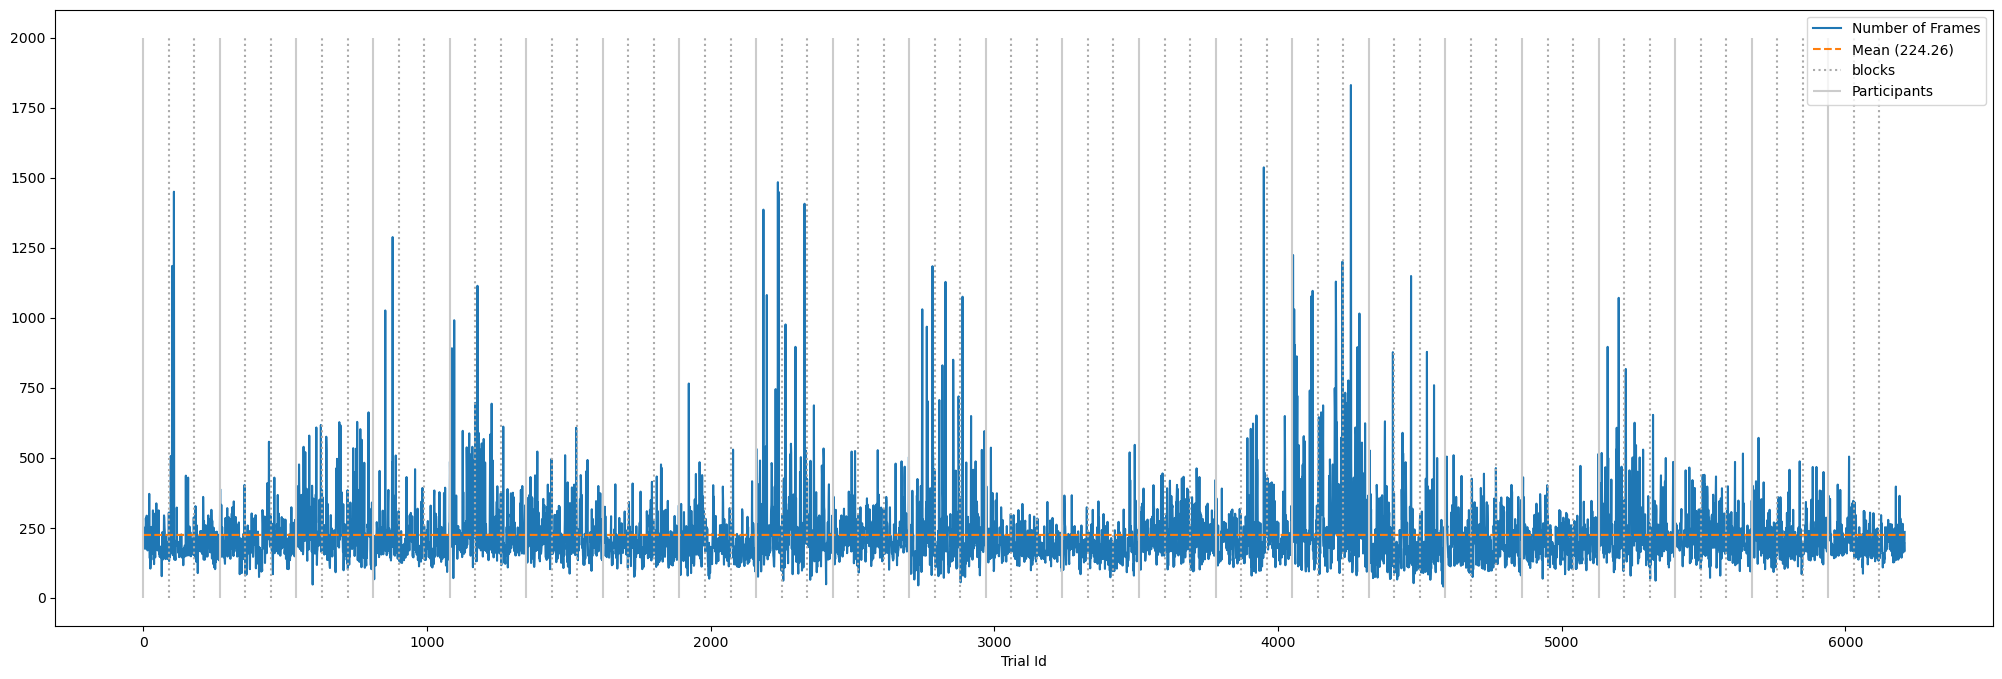

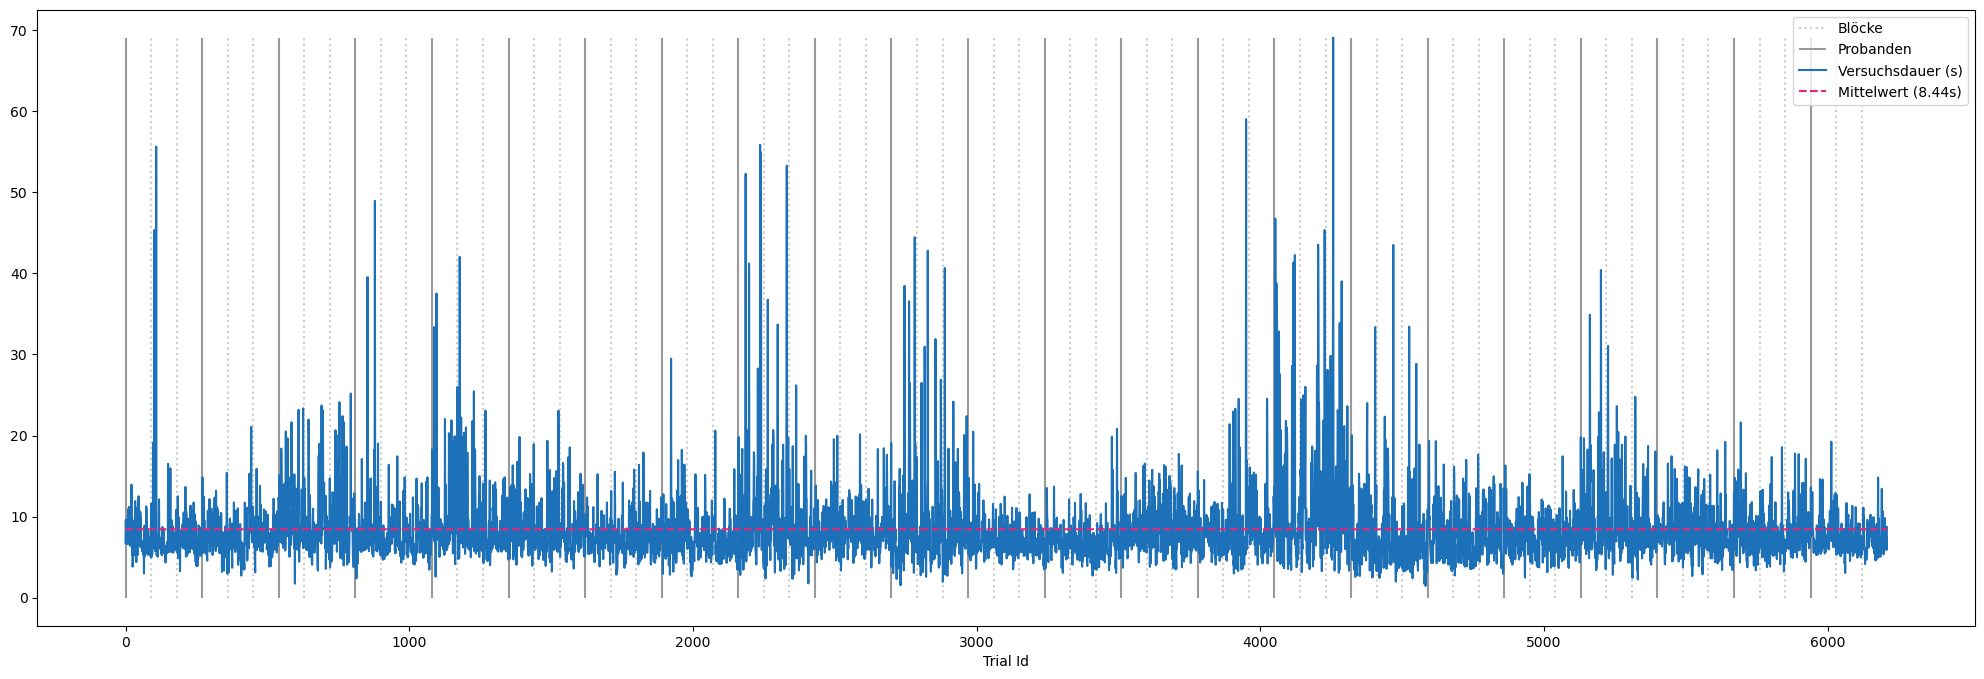

In [12]:
# proband_ids = cleaned_data['Proband'].drop_duplicates()
# proband_data = []

# display(proband_ids)

# # iterate through all probands
# for proband in proband_ids:

#     print(proband)

#     start = cleaned_data[(cleaned_data['posX'] == " START") & (cleaned_data['Proband'] == proband)] 
#     finish = cleaned_data[((cleaned_data["posX"] == " COMPLETED") | (cleaned_data["posX"] == " FAILED") | (cleaned_data["posX"] == " TERMINATED") & cleaned_data['Proband'] == proband)]
       
#     # remove duplicate labels (keep last)
#     start = start.drop_duplicates(['Task', 'Trial'], keep='last')
           
#     # remove duplicate labels (keep first)
#     finish = finish.drop_duplicates(['Task', 'Trial'], keep='first')
        
#     # setting the indices - associate the date sets with each other - nth start <-> nth finish 
#     finish["FrameNumber_Start"] = start.index
#     start["FrameNumber_Finish"] = finish.index
    
#     start["DateTime"] = cleaned_data["DateTime"].astype("string")
#     finish["DateTime"] = cleaned_data["DateTime"].astype("string")
    
#     finish = finish.reset_index()
#     start = start.reset_index()
    
#     result = pd.DataFrame(start["mappingMethod"])
#     result = result.rename(columns= {"mappingMethod": "MappingMethod"})
    
#     result["FrameNumber_Start"] = finish["FrameNumber_Start"]
#     result["FrameNumber_Finish"] = start["FrameNumber_Finish"]
#     result["Block"] = (start["Task"] / 18).apply(np.ceil).astype(int)
#     result["Task"] = (start["Task"] - ((result["Block"] - 1) * 18)).astype(int)
#     result["Trial"] = start["Trial"].astype(int)
#     result["NumLayers"] = start["LayerCount"]    
#     result["Target"] = start["TargetLayers"].str.split(",")
#     result["Target"] = result.apply(lambda item: item["Target"][item["Trial"]], axis = 1).astype(int)
#     result["Target_Relative"] = result["Target"].astype(float) / result["NumLayers"].astype(float)

#     result["DateTime_Start"] = start["DateTime"]
#     result["DateTime_Finish"] = finish["DateTime"]

#     result["Duration"] = (pd.to_datetime(finish["DateTime"], format=timeFormat) - pd.to_datetime(start["DateTime"], format=timeFormat)).dt.total_seconds()
#     result["NumFrames"] = start["FrameNumber_Finish"]- finish["FrameNumber_Start"]
#     result["Result"] = finish["posX"]
    
#     result["Proband"] = start["Proband"]

#     result["FrameRate_1"] = result["NumFrames"] / result["Duration"]
    
#     proband_data.append(result)

# allTimes = pd.concat(proband_data, ignore_index=True)
# display(allTimes)

allTimes = cleaned_data

# descriptive statistics for Duration, FrameRate, Number of Frames per Trial
stats = pd.DataFrame(allTimes["Duration_CleanedUp_Computed"])
stats['Duration'] = stats['Duration_CleanedUp_Computed']
stats.drop(columns=['Duration_CleanedUp_Computed'], inplace=True)
stats["NumFrames"] = allTimes["NumFrames_CleanedUp"]
stats["FrameRate"] = stats["NumFrames"] / stats["Duration"]

stats_desc = stats.describe()
display(stats_desc)

target_fps1 = 25
target_fps2 = 28.2

print("outliers: fps < " + str(target_fps1))

outliers1 = stats[1.0 / stats["FrameRate"] > (1.0 / target_fps1)]

display(outliers1)

print("outliers: fps > " + str(target_fps2))

outliers2 = stats[1.0 / stats["FrameRate"] < (1.0 / target_fps2)]

display(outliers2)

print("BlockStarts")

blockStarts = allTimes[(allTimes["Task"] == 1) & (allTimes["Trial"] == 0)]

display(blockStarts)

vlines_x = blockStarts[blockStarts['Block'] > 1].index
vlines_x2 = blockStarts[blockStarts['Block'] == 1].index

y_mean = pd.DataFrame([stats_desc["NumFrames"][1]]*len(allTimes))

fig1,ax1 = plt.subplots(figsize=(25,8))

ax1.plot(allTimes["NumFrames_CleanedUp"], label="Number of Frames")
ax1.set_xlabel("Trial Id")
ax1.plot(y_mean, label=f'Mean ({stats_desc["NumFrames"][1]:.2f})', linestyle='--')

ax1.vlines(x=vlines_x, ymin=0, ymax=2000, color='#AAAAAA', linestyles=':', label='blocks')
ax1.vlines(x=vlines_x2, ymin=0, ymax=2000, color='#CCCCCC', linestyles='-', label='Participants')

legend1 = ax1.legend(loc='upper right')

fig1.savefig(rf'{export_img}numFrames_cleaned-{numSamplesForRemoval}.png')
fig1.savefig(rf'{export_img}numFrames-{numSamplesForRemoval}.svg')

y_mean = pd.DataFrame([stats_desc["Duration"][1]]*len(allTimes))

fig2, ax2 = plt.subplots(figsize=(25,8))

ax2.vlines(x=vlines_x, ymin=0, ymax=stats_desc["Duration"]["max"], color='#CCCCCC', linestyles=':', label='Blöcke')
ax2.vlines(x=vlines_x2, ymin=0, ymax=stats_desc["Duration"]["max"], color='#999999', linestyles='-', label='Probanden')
ax2.plot(allTimes["Duration_CleanedUp_Computed"], color='#1d71b8', label="Versuchsdauer (s)")
ax2.set_xlabel("Trial Id")
ax2.plot(y_mean, label=f'Mittelwert ({y_mean[0][0]:.2f}s)', color='#e7267a', linestyle='--')



legend2 = ax2.legend(loc='upper right')

fig2.savefig(rf'{export_img}times-{numSamplesForRemoval}.png')
fig2.savefig(rf'{export_img}times-{numSamplesForRemoval}.svg')